# Advanced Tutorial: Mastering py-sphviewer2

While the high-level `render()` function is fantastic for quick, out-of-the-box visualizations, the true power of **py-sphviewer2** lies in its Object-Oriented pipeline and the underlying nested grids engine. 

In this tutorial, we will bypass the wrapper function and interact directly with the core C++ engine. We will build a complete visualization pipeline that allows us to tilt the camera, extract the multi-scale resolution levels of our simulation, and utilize Deferred Rendering to instantly save and load massive projections without keeping the raw particle data in memory.

We will do this for the dark matter component of the simulation, so we will need to estimate the smoothing lengths of the particles.

### What we will do:

* **Exact KNN Smoothing Lenghts:** Using the multi-threaded `estimate_h` function to perform an exact 32-nearest-neighbor search across periodic boundaries.
* **The Object-Oriented-Pipeline (OOP) Pipeline:** Separating our data into `Particles`, `Camera`, and `Projector` objects to unlock hardware-efficient C++ matrix rotations.
* **Deferred Rendering:** Baking the active grid hierarchy to an incredibly small `.hdf5` file and immediately dropping the heavy raw arrays from RAM.
* **Multi-Scale Deconstruction:** Re-loading the baked grids to visually explore how the Benitez-Llambay (2025) algorithm separates particle scales before collapsing them into the final ultra-high-resolution image.
* **Real Application: Targeting Dark Matter Halos:** Loading a catalague of dark matter halos anf targeting them individually, leveraging access to a single memory buffer contatining the particle data.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sphviewer2
import math
import os
import h5py
import time

# Load the CAMELS TNG snapshot
# You can download this file from here:
# https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG/1P/1P_p11_2/snapshot_090.hdf5
file_path = './snapshot_090.hdf5'
print(f"Loading data from {file_path}...")

with h5py.File(file_path, 'r') as snap:
    # Read Gas Coordinates (x, y, z) and convert to float64
    pos_gas = snap['PartType1/Coordinates'][()]
    x = pos_gas[:, 0]
    y = pos_gas[:, 1]
    z = pos_gas[:, 2]
    
    # Read Gas Masses
    m = snap['Header'].attrs['MassTable'][1] * np.ones(len(x)) * 1e10  # Convert to M_sun/h
    
    # Read Box Size from Header
    Lbox = snap['Header'].attrs['BoxSize']
    
print(f"Loaded {len(x):,} gas particles.")
print(f"Box Size: {Lbox:.2f} ckpc/h")

Loading data from ./snapshot_090.hdf5...
Loaded 16,777,216 gas particles.
Box Size: 25000.00 ckpc/h


## Calculating Smoothing Lengths

Using the optimized `estimate_h` function, we perform an exact, multi-threaded $K$-nearest neighbor search across the periodic boundaries. 

In [ ]:
# =============================================================================
# Nearest-Neighbor Smoothing (K=32)
# =============================================================================

print("Calculating exact smoothing lengths (h)...")
t0 = time.time()
# The C++ backend handles the periodic boundary wrapping automatically
h = sphviewer2.estimate_h(x, y, z, Lbox=Lbox, k=32, num_threads=8)
print(f"Done in {time.time() - t0:.2f} seconds.")

Calculating exact smoothing lengths (h)...
Done in 139.39 seconds.


## Calculating Smoothing Lengths

Instead of the wrapper function, we build the pipeline manually. This allows us to change the camera angle without touching the particle data.


In [ ]:
# =============================================================================
# Object-Oriented Rendering & 3D Rotations
# =============================================================================

parts = sphviewer2.Particles(x, y, z, h, m)

cam = sphviewer2.Camera(
    Lbox=Lbox, 
    extent=Lbox/4.0, 
    elevation=0.0,  
    azimuth=30.0,    
    r_min=4,         
    r_max=11,        
    target_cells_per_h=4
)

proj = sphviewer2.Projector(cam)

print("Projecting particles into the hierarchy...")
t0 = time.time()
proj.project(parts, num_threads=4)
print(f"Projection done in {time.time() - t0:.2f} seconds.")


Projecting particles into the hierarchy...
Projection done in 0.07 seconds.


## Deferred Rendering (Baking to Disk)

We can save this exact 3D projection to disk. This drops particles and only saves the sparse active grids.

In [ ]:
# =============================================================================
# Deferred Rendering (Baking to Disk)
# =============================================================================

baked_file = "galaxy_baked.hdf5"
proj.save_baked_grids(baked_file, float32=True)
size_mb = os.path.getsize(baked_file) / (1024 * 1024)
print(f"Baked HDF5 size: {size_mb:.2f} MB")

# Delete the original memory-heavy objects
del parts, proj

Baked HDF5 size: 2.08 MB


## Loading a Baked File for Deferred Rendering

We can load the baked file, which contains a lightweight sparse representation of the active grids, and reconstruct the image at the highest resolution.

Loading baked grids...


/var/folders/97/r_c45wkd08q9fthb_shw5p0c0000gn/T/ipykernel_1324/1844912952.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


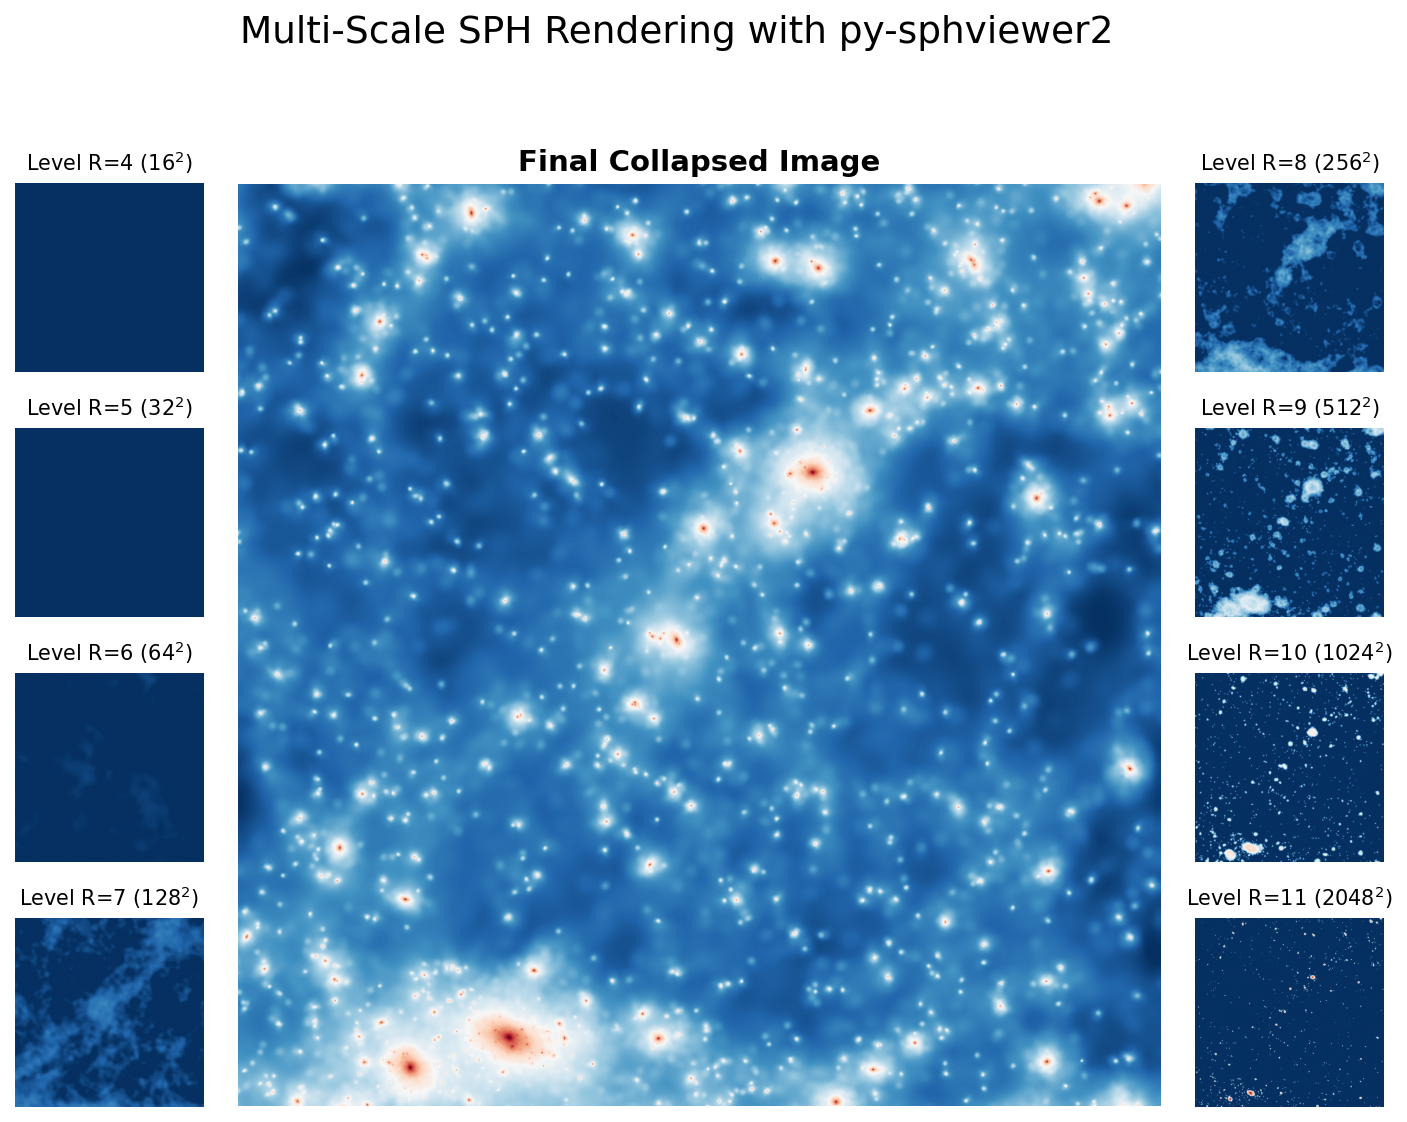

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =============================================================================
# Exploring the Multi-Scale Hierarchy as Deferred Rendering
# =============================================================================

print("Loading baked grids...")
proj_loaded = sphviewer2.Projector.load_baked_grids(baked_file)

# Extract the individual resolution scales
r_min = proj_loaded.camera.r_min
r_max = proj_loaded.camera.r_max
n_levels = r_max - r_min + 1

# Determine how many rows we need (half on the left, half on the right)
n_rows = math.ceil(n_levels / 2)


# Plotting part
fig = plt.figure(figsize=(12, 8), dpi=150)
gs = gridspec.GridSpec(n_rows, 6, figure=fig, wspace=0.1, hspace=0.3)
side_axes = []
for i in range(n_rows):
    side_axes.append(fig.add_subplot(gs[i, 0]))

for i in range(n_rows):
    side_axes.append(fig.add_subplot(gs[i, 5]))

ax_center = fig.add_subplot(gs[:, 1:5])

vmin, vmax = 5.5, 9

for i, r in enumerate(range(r_min, r_max + 1)):
    level_data = proj_loaded.get_level(r)
    ax = side_axes[i]
    ax.imshow(np.log10(level_data + 1e-8), cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Level R={r} ({2**r}$^2$)", fontsize=10)
    ax.axis('off')

for j in range(n_levels, len(side_axes)):
    side_axes[j].axis('off')

# Collapse everything into the final image in the center
final_img = proj_loaded.collapse()
ax_center.imshow(np.log10(final_img + 1e-8), cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
ax_center.set_title("Final Collapsed Image", fontsize=14, fontweight='bold')
ax_center.axis('off')

plt.suptitle("Multi-Scale SPH Rendering with py-sphviewer2", fontsize=18, y=1.02)
plt.tight_layout() 
plt.show()

## Real Application: Targeting Dark Matter Halos

Now that we understand the core mechanics, let's use **py-sphviewer2** to explore individual halos. We will use a catalog of halos obtained also in the [CAMELS project website](https://camels.readthedocs.io/).

This section demonstrates one of the most powerful and time-saving features of the Object-Oriented pipeline: **Zero-Cost Spatial Masking.**

In traditional visualization workflows, zooming into a tiny halo within a massive, periodic simulation box requires writing slow Python code to calculate distances, handle periodic wrapping boundaries, and slice arrays to isolate the particles you want. 

With `py-sphviewer2`, you skip that entirely. You simply feed the *entire* universe into the engine, set your `Camera` target coordinates (`xc, yc, zc`), and define your field-of-view (`extent`) to match the halo's virial radius. The C++ backend inherently handles the periodic wrapping and drops particles outside the camera's boundaries, saving you massive amounts of memory overhead.

*(Note: To run this exact block, you will need the `groups_090.hdf5` catalog from the CAMELS public data release).*

Loading data from ./groups_090.hdf5...
Loaded 20,457 Groups and 18,408 Subhalos
Projecting particles into the hierarchy...
Projection done in 0.11 seconds.


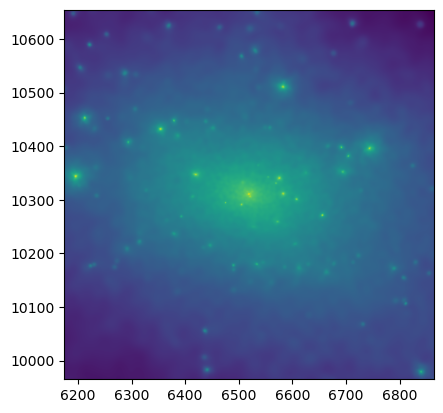

In [ ]:
# You can get the file from https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG/1P/1P_p11_2/groups_090.hdf5
groups_path = "./groups_090.hdf5"

print(f"Loading data from {groups_path}...")
with h5py.File(groups_path, 'r') as snap:
    # Read Group Coordinates
    GroupFirstSub = snap['Group/GroupFirstSub'][()]
    GroupCM = snap['Group/GroupCM'][()]
    Group_R_Crit200 = snap['Group/Group_R_Crit200'][()]
    SubhaloPos = snap['Subhalo/SubhaloPos'][()]

print(f"Loaded {len(GroupCM):,} Groups and {len(SubhaloPos):,} Subhalos")

parts = sphviewer2.Particles(x, y, z, h, m)

# Look at group 0 only
group_id = 0

cam = sphviewer2.Camera(
    Lbox=Lbox, 
    extent=Group_R_Crit200[group_id], 
    xc = SubhaloPos[GroupFirstSub[group_id],0],
    yc = SubhaloPos[GroupFirstSub[group_id],1],
    zc = SubhaloPos[GroupFirstSub[group_id],2],
    r_min=4,         
    r_max=11,        
    target_cells_per_h=4
)

proj = sphviewer2.Projector(cam)

print("Projecting particles into the hierarchy...")
t0 = time.time()
proj.project(parts, num_threads=4)
print(f"Projection done in {time.time() - t0:.2f} seconds.")

image = proj.collapse()
extent = proj.camera.get_extent()

plt.imshow(np.log10(image+1e-5), extent=extent, origin='lower')
plt.show()

## Multi-Object Rendering: The 16 Most Massive Halos

Because **py-sphviewer2** strictly separates the `Particles` data from the `Camera` and `Projector`, we never need to duplicate or rebuild our massive particle arrays just to look at different regions of the simulation. We can simply keep the master `parts` object sitting in memory and fly the camera around the universe!

In this final block, we will loop through the top 16 most massive groups in the simulation. For each step in the loop, we simply update the camera's center to the target subhalo, scale the field-of-view to its virial radius, and trigger a new projection. 

Notice how incredibly fast the C++ backend chunks through the global dataset to render 16 distinct, high-resolution views on the fly, all from the exact same memory buffer. In this particular example, projecting the particles of all the halos is actually cheaper than the call to matplotlib to produce the image.

Projecting particles...
Projection done in 1.01 seconds.


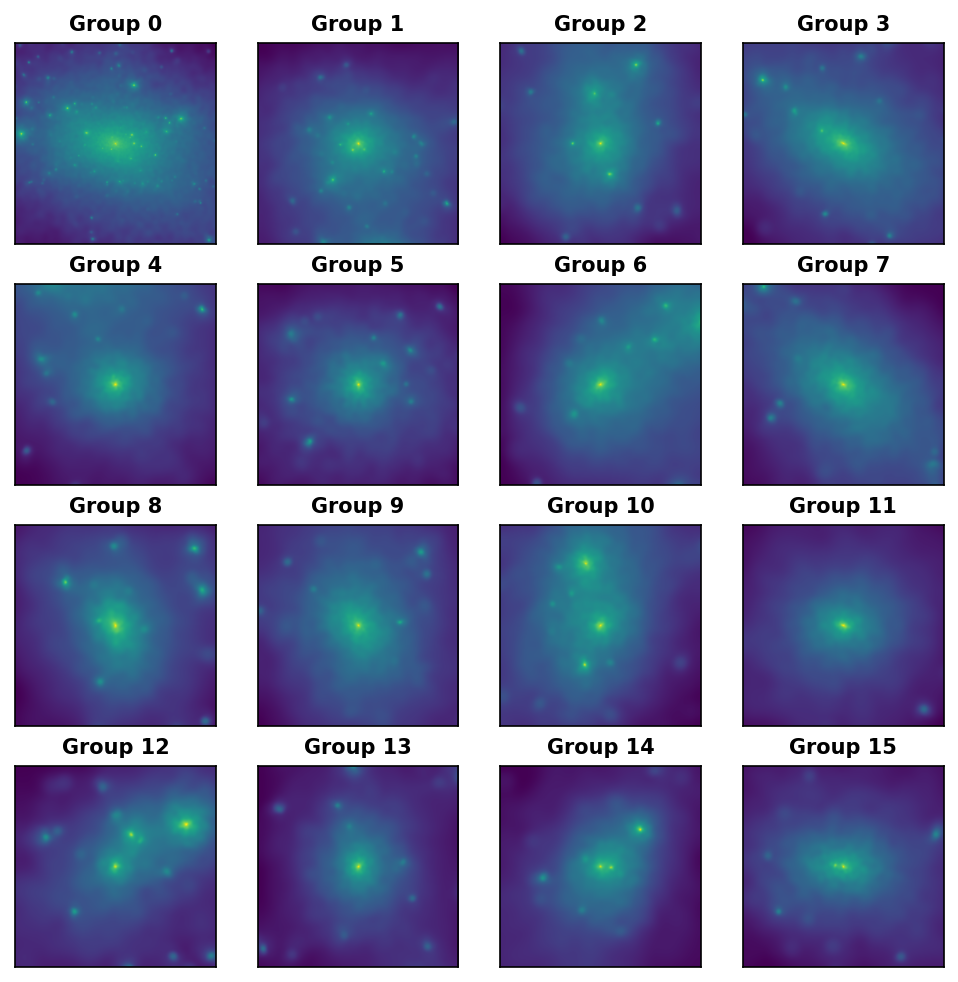

In [ ]:
fig, axes = plt.subplots(figsize=(8,8), ncols=4, nrows=4, dpi=150)

print("Projecting particles...")

t0 = time.time()
for i in range(16):
    group_id = i
    cam.xc = SubhaloPos[GroupFirstSub[group_id],0]
    cam.yc = SubhaloPos[GroupFirstSub[group_id],1]
    cam.zc = SubhaloPos[GroupFirstSub[group_id],2]
    cam.extent = Group_R_Crit200[group_id]
    proj = sphviewer2.Projector(cam)

    proj.project(parts, num_threads=4)

    image = proj.collapse()
    extent = proj.camera.get_extent()
    axes.flatten()[i].imshow(np.log10(image+1e-5), extent=extent, origin='lower')
    axes.flatten()[i].xaxis.set_visible(False)
    axes.flatten()[i].yaxis.set_visible(False)
    axes.flatten()[i].set_title(f"Group {group_id}", fontsize=10, fontweight='bold')
    
print(f"Projection done in {time.time() - t0:.2f} seconds.")
plt.show()